# Tarea 1
Primero se importa la imagen "sopa_letras.png".

Una vez importada continuamos:

In [3]:
%pip install numpy matplotlib opencv-python

   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ------------- -------------------------- 14.4/44.0 MB 81.5 MB/s eta 0:00:01
   ------------------------------- -------- 34.3/44.0 MB 90.2 MB/s eta 0:00:01
   ---------------------------------------- 44.0/44.0 MB 80.6 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\Nvrrou\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("sopa_letras.png")

### Binarización de la imagen
Se pasará la imagen de RGB a escala de grises, ya que `findContours` lo requiere, y luego a binario, así separando de mejor manera las regiones, para que las funciones puedan funcionar mas eficiente.

Esto se hará con la función `cvtColor` para pasarla a escala de grises y `threshold` para binarizarla.

In [9]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
th, binary = cv2.threshold(gray, 0, 255,cv2.THRESH_BINARY_INV)

### Segmentación de Regiones
Primero se separará cada letra en regiones con `findContours`

In [10]:
contours, _ = cv2.findContours(
    binary,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

## Calculo

## Imagen con centro de masa y indices de cada contorno
Para ubicar efectivamente donde estamos haciendo cada calculo, se hara inmediatamente el calculo de los centro de masa de cada contorno, para luego poner su indice y tener un indicador visual de los contornos ocupados.

In [30]:
img_cm_n = img.copy()

# Calculo de centro de masa y enumeración
for i, contour in enumerate(contours):
    cv2.drawContours(img_cm_n, contours, i, (0, 255, 0), 2)

    # Obtener un punto dentro/cerca del contorno
    M = cv2.moments(contour)

    if M["m00"] != 0:
        x = int(M["m10"] / M["m00"])
        y = int(M["m01"] / M["m00"])
    else:
        x, y = contour[0][0]

    cv2.circle(img_cm_n, (x, y), 3, (255, 0, 0), -1)

    cv2.putText(
        img_cm_n,
        str(i),
        (x + 5, y+5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 0, 0),
        2
    )

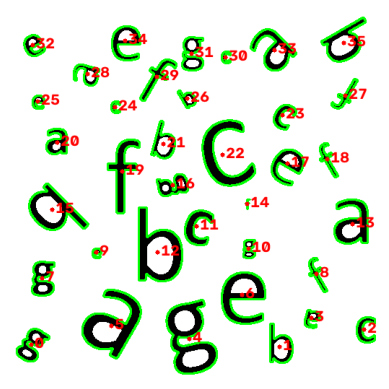

In [31]:
cv2.imshow("Imagen enumerada por contorno", img_cm_n) #imagen enumerada por contorno

plt.imshow(img_cm_n, cmap="winter")
plt.axis("off")
plt.show()

In [ ]:
img_cm = img.copy()

# Calculo de centro de masa
for i, contour in enumerate(contours):

    M = cv2.moments(contour)

    if M["m00"] != 0:
        #Redondeamos para que la imagen quede legible
        x = round(float(M["m10"] / M["m00"]),3)
        y = round(float(M["m01"] / M["m00"]),3)
    else:
        x, y = contour[0][0]

    cv2.circle(img_cm, (int(x), int(y)), 3, (255, 0, 0), -1)

    print(f"Contorno: {i}")
    print(f"  Centro de masa: ({x}, {y})")

Contorno: 0
  Centro de masa: (29.672, 464.591)
Contorno: 1
  Centro de masa: (373.91, 467.866)
Contorno: 2
  Centro de masa: (490.838, 443.638)
Contorno: 3
  Centro de masa: (417.588, 427.301)
Contorno: 4
  Centro de masa: (248.715, 456.225)
Contorno: 5
  Centro de masa: (140.568, 438.525)
Contorno: 6
  Centro de masa: (321.624, 395.171)
Contorno: 7
  Centro de masa: (44.712, 372.896)
Contorno: 8
  Centro de masa: (424.408, 366.405)
Contorno: 9
  Centro de masa: (119.694, 336.809)
Contorno: 10
  Centro de masa: (330.592, 331.583)
Contorno: 11
  Centro de masa: (258.163, 300.986)
Contorno: 12
  Centro de masa: (204.534, 336.03)
Contorno: 13
  Centro de masa: (474.492, 297.611)
Contorno: 14
  Centro de masa: (328.533, 269.3)
Contorno: 15
  Centro de masa: (58.398, 277.363)
Contorno: 16
  Centro de masa: (225.686, 243.94)
Contorno: 17
  Centro de masa: (384.454, 213.618)
Contorno: 18
  Centro de masa: (439.408, 207.405)
Contorno: 19
  Centro de masa: (155.261, 224.69)
Contorno: 20
  Cent

: 

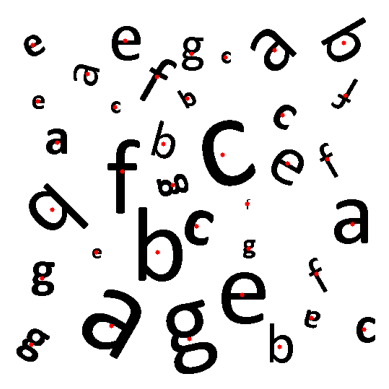

In [45]:
cv2.imshow("Imagen con centro de masa", img_cm) # imagen con centro de masa y coordenada aproximada a 2 decimales c:

plt.imshow(img_cm, cmap="gray")
plt.axis("off")
plt.show()


### Cuatro Primeros Momentos de Hu
Para esto se utilizará la funcion `cvt.moments()` la cual calcula todos los **momentos centrales normalizados** de manera eficiente y los pone en un diccionario. Es decir, nos devuelve $\eta_{rs}$.
- $m_{rs}$: 
$$
m_{rs}= \sum_{i,j\in R} i^r + j^s
$$
- $\mu_{rs}$: 
$$
\mu_{rs}= \sum_{i,j\in R} (i^r - \hat{i}) + j^s - \hat{j})
$$
Donde: $(\hat{i}, \hat{i}) = (\frac{m_{10}}{m_{00}},\frac{m_{01}}{m_{00}})$
- $\eta_{rs}$:
$$
\eta_{rs} = \frac{\mu_{rs}}{\mu_{00}^t}
$$
Donde: $t = \frac{r+s}{2} + 1$

`cvt.moments()` tambien calcula los otros momentos, pero en esta sección se utilizan los normalizados para calcular los Momentos de Hu

#### Calculo de momentos de Hu
Ya obtenidos los resultados de cada $\eta_{rs}$, calculamos cada momento de Hu, definiendo las funciones para estos.

**Primer Momento de Hu**
$$
\phi_1 = \eta_{20} + \eta_{02}
$$

In [ ]:
def prim_m_hu(etas):
  momento = etas["nu20"] + etas["nu02"]
  return momento

**Segundo Momento de Hu**
$$
\phi_2 = (\eta_{20} - \eta_{02})^2 + 4\eta_{11}^2
$$

In [ ]:
def seg_m_hu(etas):
  momento = (etas["nu20"] - etas["nu02"])**2 + 4*(etas["nu11"])**2
  return momento

**Tercer Momento de Hu**
$$
\phi_3 = (\eta_{30} - 3\eta_{12})^2 + (3\eta_{21} - \eta_{03})^2
$$

In [ ]:
def ter_m_hu(etas):
  momento = (etas["nu30"]-3*etas["nu12"])**2 + (3*etas["nu21"]-etas["nu03"])**2
  return momento

**Cuarto Momento de Hu**
$$
\phi_4 = (\eta_{30} + \eta_{12})^2 + (\eta_{21} + \eta_{03})^2
$$

In [ ]:
def cuar_m_hu(etas):
  momento = (etas["nu30"] + etas["nu12"])**2 + (etas["nu21"] + etas["nu03"])**2
  return momento

Finalmente calculamos para cada contorno:

In [ ]:
cont = 0
for contorno in contours:
  momento = cv2.moments(contorno)
  print(f"contorno: {cont}")
  print(prim_m_hu(momento))
  print(seg_m_hu(momento))
  print(ter_m_hu(momento))
  print(cuar_m_hu(momento))
  cont+=1


contorno: 0
0.23857889053657783
0.016747333654413672
0.000243453495255348
5.514086787180561e-05
contorno: 1
0.19765244860962494
0.0051186693163705315
0.0018127570819340946
0.0006025360147033739
contorno: 2
0.40176397174294454
0.03114436130723395
0.010397787452780388
0.0032998449229916585
contorno: 3
0.22377443071282385
0.00333723225120393
0.0009214682232930947
0.0004298547997427773
contorno: 4
0.2521188756514213
0.021046405467978892
0.0003163655850604808
5.4612201568793305e-05
contorno: 5
0.23794518541992743
0.005191644204468359
0.0013152431190909667
0.0010269906556124898
contorno: 6
0.24782358293142137
0.002597758862775241
0.0005348195504826978
0.0012894927385207096
contorno: 7
0.24011998210753643
0.017136732372953493
0.00022488688322923865
5.608637174617828e-05
contorno: 8
0.6132328486529779
0.29116704051206577
0.036704204891691246
0.012319245023104764
contorno: 9
0.2234685689007052
0.001043506869521679
0.00028723516132550113
0.00048823492716504313
contorno: 10
0.24534336995961178
0.

###